# Comparing MERT and CultureMERT for Raga Representation Learning

The objective of this project is to compare MERT and CultureMERT, two self-supervised audio representation models, on Indian classical music.

MERT is a general-purpose music representation model trained on large-scale music data, while CultureMERT is adapted to better capture culturally specific musical characteristics.

The comparison is performed using the Saraga dataset through embedding visualization and supervised classification experiments.

In [173]:
!pip install -q torch
!pip install -q torchaudio
!pip install -q transformers
!pip install -q librosa
!pip install -q numpy
!pip install -q pandas
!pip install -q tqdm
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q umap-learn
!pip install -q mirdata

In [174]:
import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm

# Dataset

We use the Saraga dataset, a collection of Indian classical music recordings.

Initially, experiments were conducted on the Saraga Hindustani subset. However, most ragas had only a single recording, making supervised evaluation difficult.

We therefore explored the Saraga Carnatic subset and selected only ragas with at least two recordings.

Final dataset statistics:

- 47 recordings
- 16 ragas
- Multiple recordings available for each selected raga

This subset enables basic classification experiments and embedding analysis.

In [175]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
!unzip -q "/content/drive/MyDrive/saraga1.5_carnatic.zip" -d "/content/saraga_carnatic"

replace /content/saraga_carnatic/saraga1.5_carnatic/file_paths.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/saraga_carnatic/__MACOSX/saraga1.5_carnatic/._file_paths.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/saraga_carnatic/__MACOSX/saraga1.5_carnatic/._Sumitra Nitin at Arkay by Sumitra Nitin? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [114]:
!du -sh /content/saraga_carnatic

11G	/content/saraga_carnatic


In [115]:
!find /content/saraga_carnatic -name "*.mp3" | wc -l

1419


In [116]:
!ls "/content/saraga_carnatic"

__MACOSX  saraga1.5_carnatic


In [117]:
import mirdata

carnatic = mirdata.initialize(
    "saraga_carnatic",
    data_home="/content/saraga_carnatic"
)

carnatic.download(partial_download=["index"])

In [118]:
tracks_c = carnatic.load_tracks()

print("Number of tracks:", len(tracks_c))

Number of tracks: 249


In [119]:
for track in tracks_c.values():

    if len(track.metadata["raaga"]) > 0:

        print(track.metadata["title"])
        print(track.metadata["raaga"])
        break

Thillana Purnachandrika
[{'uuid': 'd5f3448e-3665-4721-ac85-5b1cdea1d92b', 'name': 'Pūrṇacandrika'}]


In [120]:
from collections import Counter

all_ragas = []

for track in tracks_c.values():

    try:
        for raga in track.metadata["raaga"]:

            if "name" in raga:
                all_ragas.append(raga["name"])

    except Exception:
        continue

print("Total raga annotations:", len(all_ragas))
print("Unique ragas:", len(set(all_ragas)))

counter = Counter(all_ragas)

print("\nTop 30 ragas:\n")

for raga, count in counter.most_common(30):
    print(raga, ":", count)

Total raga annotations: 133
Unique ragas: 80

Top 30 ragas:

Tōḍi : 6
Kamās : 6
Rāgamālika : 6
Saurāṣtraṁ : 6
Behāg : 5
Ṣanmukhapriya : 4
Kalyāṇi : 4
Suraṭi : 3
Bēgaḍa : 3
Bhairavi : 3
Śankarābharaṇaṁ : 3
Rītigauḷa : 3
Pūrṇacandrika : 2
Lalita : 2
Ābhōgi : 2
Harikāmbhōji : 2
Kāpi : 2
Sindhubhairavi : 2
Sāvēri : 2
Mārgahindōḷaṁ : 2
Nādanāmakriya : 2
Kāṁbhōji : 2
Madhyamāvati : 2
Gauḷa : 2
Kānaḍa : 2
Śudda sāvēri : 1
Mōhanaṁ : 1
Lalita pancamaṁ : 1
Latāngi : 1
Hamsadhvani : 1


In [121]:
audio_files = []
labels = []

for track in tracks_c.values():

    try:
        metadata = track.metadata

        if len(metadata["raaga"]) > 0:

            audio_files.append(track.audio_path)

            labels.append(
                metadata["raaga"][0]["name"]
            )

    except Exception:
        continue

print("Audio files:", len(audio_files))
print("Labels:", len(labels))
print("Unique ragas:", len(set(labels)))

Audio files: 133
Labels: 133
Unique ragas: 80


In [122]:
from collections import Counter

counter = Counter(labels)

for raga, count in counter.most_common():
    if count >= 2:
        print(raga, ":", count)

Tōḍi : 6
Kamās : 6
Rāgamālika : 6
Saurāṣtraṁ : 6
Behāg : 5
Ṣanmukhapriya : 4
Kalyāṇi : 4
Suraṭi : 3
Bēgaḍa : 3
Bhairavi : 3
Śankarābharaṇaṁ : 3
Rītigauḷa : 3
Pūrṇacandrika : 2
Lalita : 2
Ābhōgi : 2
Harikāmbhōji : 2
Kāpi : 2
Sindhubhairavi : 2
Sāvēri : 2
Mārgahindōḷaṁ : 2
Nādanāmakriya : 2
Kāṁbhōji : 2
Madhyamāvati : 2
Gauḷa : 2
Kānaḍa : 2


In [123]:
from collections import Counter

counter = Counter(labels)

repeated = {}

for raga, count in counter.items():
    if count >= 2:
        repeated[raga] = count

print("Repeated ragas:", len(repeated))

for raga, count in sorted(repeated.items(),
                          key=lambda x: x[1],
                          reverse=True):
    print(raga, ":", count)

Repeated ragas: 25
Tōḍi : 6
Kamās : 6
Rāgamālika : 6
Saurāṣtraṁ : 6
Behāg : 5
Ṣanmukhapriya : 4
Kalyāṇi : 4
Suraṭi : 3
Bēgaḍa : 3
Bhairavi : 3
Śankarābharaṇaṁ : 3
Rītigauḷa : 3
Pūrṇacandrika : 2
Lalita : 2
Ābhōgi : 2
Harikāmbhōji : 2
Kāpi : 2
Sindhubhairavi : 2
Sāvēri : 2
Mārgahindōḷaṁ : 2
Nādanāmakriya : 2
Kāṁbhōji : 2
Madhyamāvati : 2
Gauḷa : 2
Kānaḍa : 2


In [124]:
from collections import Counter

counter = Counter(labels)

valid_ragas = {
    raga
    for raga, count in counter.items()
    if count >= 2
}

audio_files_rep = []
labels_rep = []

for audio, label in zip(audio_files, labels):

    if label in valid_ragas:
        audio_files_rep.append(audio)
        labels_rep.append(label)

print("Tracks:", len(audio_files_rep))
print("Classes:", len(set(labels_rep)))

Tracks: 78
Classes: 25


In [176]:
from collections import Counter

Counter(labels_rep)

Counter({'Pūrṇacandrika': 2,
         'Suraṭi': 3,
         'Tōḍi': 6,
         'Kamās': 6,
         'Lalita': 2,
         'Ābhōgi': 2,
         'Rāgamālika': 6,
         'Bēgaḍa': 3,
         'Behāg': 5,
         'Bhairavi': 3,
         'Saurāṣtraṁ': 6,
         'Harikāmbhōji': 2,
         'Śankarābharaṇaṁ': 3,
         'Kāpi': 2,
         'Sindhubhairavi': 2,
         'Rītigauḷa': 3,
         'Sāvēri': 2,
         'Ṣanmukhapriya': 4,
         'Kalyāṇi': 4,
         'Mārgahindōḷaṁ': 2,
         'Nādanāmakriya': 2,
         'Kāṁbhōji': 2,
         'Madhyamāvati': 2,
         'Gauḷa': 2,
         'Kānaḍa': 2})

In [178]:
import numpy as np

np.save("carnatic_audio_files.npy", np.array(audio_files_rep))
np.save("carnatic_labels.npy", np.array(labels_rep))

In [179]:
from collections import Counter

counter = Counter(labels_rep)

print("Unique labels:", len(counter))

Unique labels: 25


In [180]:
import torch
from transformers import AutoModel

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

mert = AutoModel.from_pretrained(
    "m-a-p/MERT-v1-95M",
    trust_remote_code=True
)

mert = mert.to(device)
mert.eval()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERTModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): MERTFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): HubertEncoder(
    (pos_conv_embed): HubertPositionalConvEmbedding(
      (conv): Parametr

In [129]:
import numpy as np
import librosa
import torch
from tqdm import tqdm
import gc

mert_embeddings = []
valid_labels = []

for idx, (file, label) in enumerate(
    tqdm(
        zip(audio_files_rep, labels_rep),
        total=len(audio_files_rep)
    )
):

    try:

        audio, sr = librosa.load(
            file,
            sr=24000,
            duration=30
        )

        audio_tensor = (
            torch.tensor(audio)
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():

            outputs = mert(
                audio_tensor
            )

        embedding = (
            outputs
            .last_hidden_state
            .mean(dim=1)
            .squeeze()
            .cpu()
            .numpy()
        )

        mert_embeddings.append(
            embedding
        )

        valid_labels.append(
            label
        )

        # Free memory
        del audio_tensor
        del outputs
        torch.cuda.empty_cache()
        gc.collect()

        # Save checkpoint every 10 files
        if (idx + 1) % 10 == 0:

            np.save(
                "mert_embeddings_checkpoint.npy",
                np.array(mert_embeddings)
            )

            np.save(
                "labels_checkpoint.npy",
                np.array(valid_labels)
            )

    except Exception as e:

        print(f"Error in {file}")
        print(e)

X_mert = np.array(mert_embeddings)
y_mert = np.array(valid_labels)

print("MERT embeddings shape:", X_mert.shape)
print("Labels shape:", y_mert.shape)

100%|██████████| 78/78 [01:08<00:00,  1.13it/s]

MERT embeddings shape: (78, 768)
Labels shape: (78,)


In [ ]:
X_mert = np.array(
    mert_embeddings
)

y = np.array(
    valid_labels
)

print(X_mert.shape)
print(y.shape)

In [ ]:
np.save(
    "X_mert_saraga.npy",
    X_mert
)

np.save(
    "y_saraga.npy",
    y
)

In [ ]:
print(y[:10])

In [ ]:
import gc

del mert

gc.collect()
torch.cuda.empty_cache()

In [ ]:
from transformers import AutoModel

culture_model = AutoModel.from_pretrained(
    "ntua-slp/CultureMERT-95M",
    trust_remote_code=True
)

culture_model = culture_model.to(device)
culture_model.eval()

In [ ]:
import numpy as np
import librosa
import torch
from tqdm import tqdm

culture_embeddings = []
valid_labels = []

for file, label in tqdm(
    zip(audio_files_rep, labels_rep),
    total=len(audio_files_rep)
):

    try:

        audio, sr = librosa.load(
            file,
            sr=24000,
            duration=30
        )

        audio_tensor = (
            torch.tensor(audio)
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():

            outputs = culture_model(
                audio_tensor
            )

        embedding = (
            outputs
            .last_hidden_state
            .mean(dim=1)
            .squeeze()
            .cpu()
            .numpy()
        )

        culture_embeddings.append(
            embedding
        )

        valid_labels.append(
            label
        )

    except Exception as e:

        print(f"Error in {file}")
        print(e)

In [ ]:
X_culture = np.array(
    culture_embeddings
)

y_culture = np.array(
    valid_labels
)

print("CultureMERT shape:", X_culture.shape)
print("Labels shape:", y_culture.shape)

In [ ]:
np.save(
    "X_culture_saraga.npy",
    X_culture
)

np.save(
    "y_saraga.npy",
    y_culture
)

In [ ]:
print(X_mert.shape)
print(X_culture.shape)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_culture)

print("Number of labels:", len(le.classes_))

In [ ]:
X_mert.shape
X_culture.shape
len(le.classes_)

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_mert_2d = reducer.fit_transform(
    X_mert
)

print(X_mert_2d.shape)

In [ ]:
X_culture_2d = reducer.fit_transform(
    X_culture
)

print(X_culture_2d.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    X_mert_2d[:,0],
    X_mert_2d[:,1]
)

plt.title("MERT Embeddings - Saraga")

plt.show()

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_culture_2d[:,0],
    X_culture_2d[:,1]
)

plt.title("CultureMERT Embeddings - Saraga")

plt.show()

In [ ]:
from collections import Counter

counter = Counter(y_culture)

for label, count in counter.items():
    if count > 1:
        print(label, count)

In [146]:
from collections import Counter

counter = Counter(y_culture)

repeated_ragas = [
    label
    for label, count in counter.items()
    if count > 1
]

print(repeated_ragas)

[np.str_('Pūrṇacandrika'), np.str_('Suraṭi'), np.str_('Tōḍi'), np.str_('Kamās'), np.str_('Lalita'), np.str_('Ābhōgi'), np.str_('Rāgamālika'), np.str_('Bēgaḍa'), np.str_('Behāg'), np.str_('Bhairavi'), np.str_('Saurāṣtraṁ'), np.str_('Harikāmbhōji'), np.str_('Śankarābharaṇaṁ'), np.str_('Kāpi'), np.str_('Sindhubhairavi'), np.str_('Rītigauḷa'), np.str_('Sāvēri'), np.str_('Ṣanmukhapriya'), np.str_('Kalyāṇi'), np.str_('Mārgahindōḷaṁ'), np.str_('Nādanāmakriya'), np.str_('Kāṁbhōji'), np.str_('Madhyamāvati'), np.str_('Gauḷa'), np.str_('Kānaḍa')]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "x": X_mert_2d[:,0],
    "y": X_mert_2d[:,1],
    "label": y_culture
})

df = df[df["label"].isin(repeated_ragas)]

plt.figure(figsize=(12,8))

for label in repeated_ragas:

    subset = df[df["label"] == label]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=label
    )

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.title("MERT - Repeated Ragas")

plt.show()

In [ ]:
df = pd.DataFrame({
    "x": X_culture_2d[:,0],
    "y": X_culture_2d[:,1],
    "label": y_culture
})

df = df[df["label"].isin(repeated_ragas)]

plt.figure(figsize=(12,8))

for label in repeated_ragas:

    subset = df[df["label"] == label]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=label
    )

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.title("CultureMERT - Repeated Ragas")

plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

k = 3

nbrs = NearestNeighbors(
    n_neighbors=k+1
).fit(X_mert)

distances, indices = nbrs.kneighbors(X_mert)

same_label = 0
total = 0

for i in range(len(y_culture)):

    for j in indices[i][1:]:

        if y_culture[i] == y_culture[j]:
            same_label += 1

        total += 1

print(
    "MERT Neighbor Agreement:",
    same_label / total
)

In [ ]:
nbrs = NearestNeighbors(
    n_neighbors=k+1
).fit(X_culture)

distances, indices = nbrs.kneighbors(X_culture)

same_label = 0
total = 0

for i in range(len(y_culture)):

    for j in indices[i][1:]:

        if y_culture[i] == y_culture[j]:
            same_label += 1

        total += 1

print(
    "CultureMERT Neighbor Agreement:",
    same_label / total
)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=5000)

scores = cross_val_score(
    clf,
    X_mert,
    y_mert,
    cv=3
)

print("MERT CV Accuracy:", scores.mean())
print(scores)

In [ ]:
scores = cross_val_score(
    clf,
    X_culture,
    y_culture,
    cv=3
)

print("CultureMERT CV Accuracy:", scores.mean())
print(scores)

In [153]:
print(X_mert.shape)
print(X_culture.shape)
print(len(set(y_mert)))
print(len(set(y_culture)))

(78, 768)
(78, 768)
25
25


In [154]:
umap_mert = reducer.fit_transform(X_mert)
umap_culture = reducer.fit_transform(X_culture)

In [155]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf = SVC(kernel="rbf")

scores = cross_val_score(
    clf,
    X_mert,
    y_mert,
    cv=3
)

print("MERT SVM:", scores.mean())

MERT SVM: 0.07692307692307693


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [156]:
scores = cross_val_score(
    clf,
    X_culture,
    y_culture,
    cv=3
)

print("CultureMERT SVM:", scores.mean())

CultureMERT SVM: 0.10256410256410257


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [157]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(
    rf,
    X_mert,
    y_mert,
    cv=3
)

print(scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


0.10256410256410257


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(
    rf,
    X_culture,
    y_culture,
    cv=3
)

print(scores.mean())

In [159]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=1000,
    random_state=42
)

scores = cross_val_score(
    mlp,
    X_mert,
    y_mert,
    cv=3
)

print("MERT MLP:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


MERT MLP: 0.05128205128205129


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=1000,
    random_state=42
)

scores = cross_val_score(
    mlp,
    X_culture,
    y_culture,
    cv=3
)

print("Cultural_mert MLP:", scores.mean())

In [ ]:
print(device)

In [162]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

svm = SVC(kernel="rbf", C=1)

scores = cross_val_score(
    svm,
    X_mert,
    y_mert,
    cv=3
)

svm_mert = scores.mean()

print(svm_mert)

0.07692307692307693


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [163]:
scores = cross_val_score(
    svm,
    X_culture,
    y_culture,
    cv=3
)

svm_culture = scores.mean()

print(svm_culture)

0.10256410256410257


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [164]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_mert,
    y_mert,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    xticks_rotation=90
)

plt.show()

In [166]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    random_state=42
)

X_mert_2d = reducer.fit_transform(X_mert)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


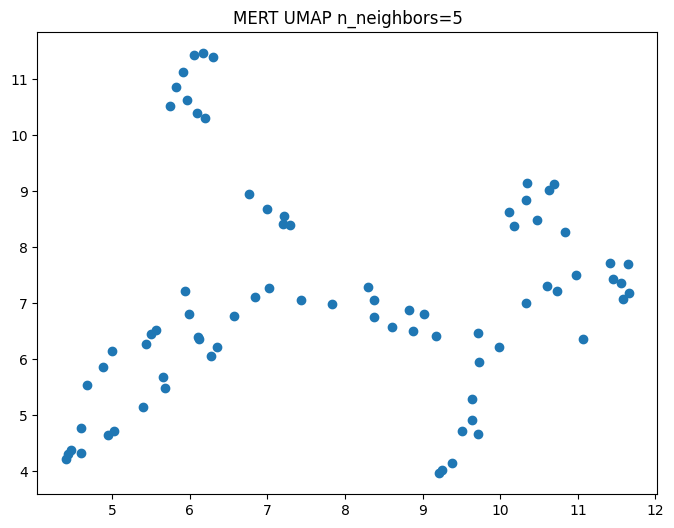

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_mert_2d[:,0],
    X_mert_2d[:,1]
)

plt.title("MERT UMAP n_neighbors=5")

plt.show()

In [168]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)

X_mert_2d = reducer.fit_transform(X_mert)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


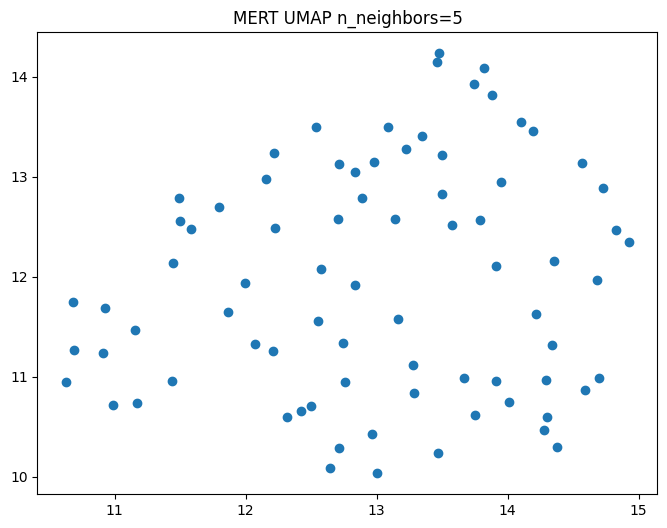

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_mert_2d[:,0],
    X_mert_2d[:,1]
)

plt.title("MERT UMAP n_neighbors=5")

plt.show()

In [170]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.01,
    random_state=42
)

X_mert_2d = reducer.fit_transform(X_mert)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


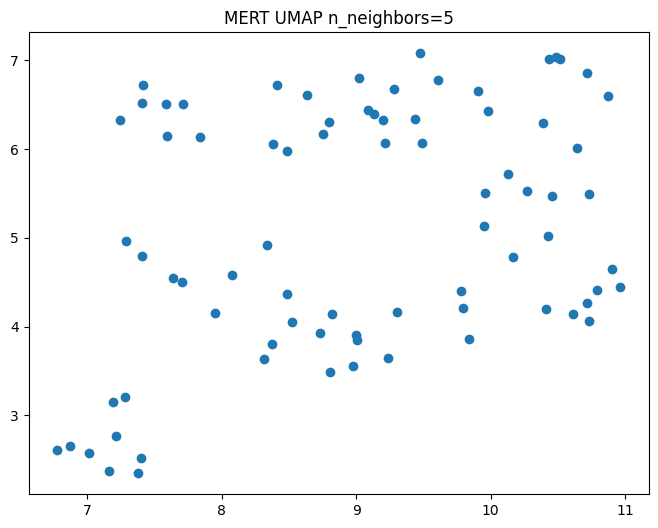

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_mert_2d[:,0],
    X_mert_2d[:,1]
)

plt.title("MERT UMAP n_neighbors=5")

plt.show()

In [172]:
import pandas as pd

results = pd.DataFrame({
    "Method":[
        "Neighbor Agreement",
        "Logistic Regression",
        "Random Forest",
        "MLP",
        "SVM"
    ],
    "MERT":[
        0.085,
        0.086,
        0.149,
        0.130,
        svm_mert
    ],
    "CultureMERT":[
        0.050,
        0.086,
        0.085,
        0.107,
        svm_culture
    ]
})

results

,Method,MERT,CultureMERT
0,Neighbor Agreement,0.085000,0.050000
1,Logistic Regression,0.086000,0.086000
2,Random Forest,0.149000,0.085000
3,MLP,0.130000,0.107000
4,SVM,0.076923,0.102564
